# Modelo Predictivo de Rendimiento y Punto de Equilibrio — Kiwi Hayward, Chimbarongo
### Gráficos del Informe N°1 (Diplomado en Data Science UC 2026)

Este notebook reconstruye, a partir de los archivos originales del huerto, **todos los gráficos y tablas**
que aparecen en el Informe N°1 (secciones 9.1 a 9.7):

1. Estadísticas descriptivas (Tabla 7)
2. Figura 1 — Distribución del rendimiento (ton/ha)
3. Figura 2 — Rendimiento por temporada de cosecha
4. Figura 3 — Curva de canopia por temporada vs. banda histórica
5. Figura 4 — Distribución de variables ambientales por temporada
6. Figura 5 — Acumulación de horas de frío y grados-día base 7 °C
7. Figura 6 — Evapotranspiración de referencia (ETo) y de cultivo proxy (ETc)
8. Figura 7 — Matriz de correlaciones
9. Figura 8 — Canopia media de temporada vs. rendimiento
10. Figura 9 — Punto de equilibrio por hectárea y escenarios de rendimiento

> **Nota metodológica:** las horas de frío y los grados-día (GDD base 7 °C y base 10 °C) no vienen
> pre-calculados en los archivos fuente, por lo que se calculan aquí con métodos agrometeorológicos
> estándar (curva horaria sinusoidal para horas de frío bajo 7,2 °C; promedio diario truncado en 0
> para GDD). Los resultados fueron validados contra las cifras del informe (coinciden con precisión
> de 1–2 decimales en la mayoría de los indicadores) y deben tratarse como una aproximación teórica,
> tal como señala la sección 8 del informe ("Paso 5, teórico"). Se recalibrarán en la Entrega N°2.


## 0. Preparar el entorno y cargar los datos

Sube la carpeta **`Datos Kiwis`** (o el .zip que la contiene) a Colab. La forma más simple:

1. Ejecuta la celda siguiente.
2. Cuando se te pida, sube el archivo `Datos_Kiwis-....zip` (el mismo que descargaste de Drive).

Si prefieres trabajar desde tu Google Drive, comenta el bloque de `files.upload()` y descomenta el
bloque de `drive.mount()`, ajustando la ruta `DATA_DIR` a la carpeta correspondiente.


In [4]:
# Instalar dependencias (Colab ya trae la mayoría; esto asegura versiones compatibles)
!pip -q install openpyxl xlrd --upgrade


In [22]:
import os, zipfile, glob

USE_DRIVE = False  # cambia a True si prefieres montar Google Drive en vez de subir el zip

if USE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    # Ajusta esta ruta a la ubicación real de la carpeta "Datos Kiwis" en tu Drive
    DATA_DIR = "/content/drive/MyDrive/Datos Kiwis"
else:
    from google.colab import files
    print("Sube el archivo .zip con la carpeta 'Datos Kiwis' (ej: Datos_Kiwis-...zip)")
    uploaded = files.upload()
    zip_name = list(uploaded.keys())[0]
    extract_dir = "/content/datos_kiwis_extraidos"
    with zipfile.ZipFile(zip_name, 'r') as z:
        z.extractall(extract_dir)
    # Buscar automáticamente la carpeta "Datos Kiwis" dentro de lo descomprimido
    candidatos = glob.glob(f"{extract_dir}/**/Datos Kiwis", recursive=True)
    DATA_DIR = candidatos[0] if candidatos else extract_dir

print("Carpeta de datos:", DATA_DIR)
print(os.listdir(DATA_DIR))


Sube el archivo .zip con la carpeta 'Datos Kiwis' (ej: Datos_Kiwis-...zip)


Saving Datos Kiwis-20260815T183246Z-1-001.zip to Datos Kiwis-20260815T183246Z-1-001 (2).zip
Carpeta de datos: /content/datos_kiwis_extraidos/Datos Kiwis
['datos_climaticos.xlsx', 'COMPARATIVO PRODUCTIVOS.xlsx', 'Kiwis 2026 Gantt planificacion.xlsx', 'Fitosanitario_Kiwis_2025_26_V2 (1).xlsx', 'datos_eto.xlsx', 'CONSOLIDADO_curvas_temporada_planet.xlsx', 'Tabla_umbral_BBCH_frio_GDD_kiwi_prompt.xlsx']


In [5]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

FOLDER = DATA_DIR


## 1. Construcción del panel productivo (cuartel × temporada)

Se reestructura la planilla `COMPARATIVO PRODUCTIVOS.xlsx` (formato ancho, con bloques de 4 filas por
cuartel) a un panel largo con una fila por combinación cuartel-temporada, tal como describe la sección
7.3 del informe.


In [6]:
raw = pd.read_excel(f"{FOLDER}/COMPARATIVO PRODUCTIVOS.xlsx", header=None)
years = raw.iloc[3, 2:10].astype(int).tolist()

records = []
r = 4
while r < raw.shape[0]:
    cuartel_id = raw.iloc[r, 0]
    if pd.isna(cuartel_id):
        r += 1
        continue
    if str(cuartel_id).strip().upper().startswith("TOTAL"):
        break
    superficie = raw.iloc[r, 1]
    bins_row    = raw.iloc[r+1, 2:10].values
    kgcuartel_row = raw.iloc[r+2, 2:10].values
    kgha_row    = raw.iloc[r+3, 2:10].values
    for i, yr in enumerate(years):
        records.append(dict(
            cuartel=str(cuartel_id).strip(),
            superficie_ha=superficie,
            anio_cosecha=yr,
            bins=bins_row[i],
            kg_cuartel=kgcuartel_row[i],
            kg_ha=kgha_row[i],
        ))
    r += 4

panel = pd.DataFrame(records)
panel['ton_ha'] = panel['kg_ha'] / 1000

# La temporada agrícola va del 1 de mayo al 30 de abril; el año de cosecha X
# corresponde a la temporada (X-1)-X (ej.: cosecha 2024 -> temporada 2023-2024)
panel['temporada'] = panel['anio_cosecha'].apply(lambda y: f"{y-1}-{y}")

# Identificador de cuartel usado en la señal satelital ('c' + número; '9 Y 13' no tiene equivalente)
panel['cuartel_canopy'] = panel['cuartel'].apply(lambda x: f"c{x}" if x.isdigit() else None)

print(f"Panel productivo: {panel.shape[0]} registros de cuartel-temporada, {panel['cuartel'].nunique()} cuarteles, "
      f"{panel['temporada'].nunique()} temporadas.")
panel.head()


Panel productivo: 112 registros de cuartel-temporada, 14 cuarteles, 8 temporadas.


,cuartel,superficie_ha,anio_cosecha,bins,kg_cuartel,kg_ha,ton_ha,temporada,cuartel_canopy
0,1,3.2,2019,144.0,62798.00,19624.3750,19.624375,2018-2019,c1
1,1,3.2,2020,209.0,89368.00,27927.5000,27.927500,2019-2020,c1
2,1,3.2,2021,224.0,92288.00,28840.0000,28.840000,2020-2021,c1
3,1,3.2,2022,151.0,65938.68,20605.8375,20.605837,2021-2022,c1
4,1,3.2,2023,130.0,59043.00,18450.9375,18.450937,2022-2023,c1


## 2. Señal satelital de canopia (agregación a nivel de temporada)

Se agrega la serie diaria suavizada de canopia (`cb_invertido_suavizado`) a tres métricas por
cuartel-temporada: nivel medio (`cnp_media`), integral de la curva (`cnp_auc`, vía regla del
trapecio) y máximo (`cnp_max`). La anomalía (`cnp_anom`) aísla el efecto de la temporada restando el
promedio histórico propio de cada cuartel.


In [7]:
canopy_diario = pd.read_excel(f"{FOLDER}/CONSOLIDADO_curvas_temporada_planet.xlsx", sheet_name="Datos_diarios")

canopy_agg = canopy_diario.groupby(['cuartel', 'temporada']).apply(
    lambda g: pd.Series({
        'cnp_media': g['cb_invertido_suavizado'].mean(),
        'cnp_auc':   np.trapezoid(g['cb_invertido_suavizado'].values, g['dia_temporada'].values),
        'cnp_max':   g['cb_invertido_suavizado'].max(),
    }),
    include_groups=False
).reset_index().rename(columns={'cuartel': 'cuartel_canopy'})

hist_mean = canopy_agg.groupby('cuartel_canopy')['cnp_media'].transform('mean')
canopy_agg['cnp_anom'] = canopy_agg['cnp_media'] - hist_mean

print(f"Canopia agregada: {canopy_agg.shape[0]} combinaciones cuartel-temporada "
      f"({canopy_diario['cuartel'].nunique()} cuarteles con señal satelital).")
canopy_agg.head()


Canopia agregada: 88 combinaciones cuartel-temporada (11 cuarteles con señal satelital).


,cuartel_canopy,temporada,cnp_media,cnp_auc,cnp_max,cnp_anom
0,c1,2019-2020,0.533913,194.813503,0.655767,0.027305
1,c1,2020-2021,0.520162,189.271066,0.650941,0.013555
2,c1,2021-2022,0.516852,188.047021,0.654510,0.010244
3,c1,2022-2023,0.484724,176.342897,0.623975,-0.021884
4,c1,2023-2024,0.522860,190.779040,0.624877,0.016253


## 3. Variables climáticas: frío invernal, grados-día y precipitación

Se calculan, a partir de la serie diaria de temperatura (`datos_climaticos.xlsx`):

- **Horas de frío** (1 mayo – 31 agosto), estimadas con una curva horaria sinusoidal a partir de
  Tmín/Tmáx diarias y umbral de 7,2 °C (método estándar cuando no se dispone de registro horario).
- **Grados-día base 7 °C y base 10 °C**, acumulados desde el 1 de septiembre (inicio del "reloj
  térmico" post-dormancia) hasta el 30 de abril siguiente.
- **Precipitación acumulada** de la temporada agrícola completa (1 mayo – 30 abril).


In [8]:
clima = pd.read_excel(f"{FOLDER}/datos_climaticos.xlsx", sheet_name="datos", header=5)
clima = clima.rename(columns={
    'Tiempo UTC-4': 'fecha',
    'Temperatura del Aire Mínima ºC': 'tmin',
    'Temperatura del Aire Máxima ºC': 'tmax',
    'Humedad Relativa Mínima %': 'hr_min',
    'Humedad Relativa Máxima %': 'hr_max',
    'Precipitación Acumulada mm': 'precip',
    'Radiación Solar Mj/m²': 'rad',
})
clima['fecha'] = pd.to_datetime(clima['fecha'], format='%d-%m-%Y', errors='coerce')
clima = clima.dropna(subset=['fecha']).copy()
for c in ['tmin', 'tmax', 'hr_min', 'hr_max', 'precip', 'rad']:
    clima[c] = pd.to_numeric(clima[c], errors='coerce')

clima['tmean'] = (clima['tmin'] + clima['tmax']) / 2
clima['gdd7']  = (clima['tmean'] - 7).clip(lower=0)
clima['gdd10'] = (clima['tmean'] - 10).clip(lower=0)

def chill_hours(tmin, tmax, threshold=7.2):
    """Horas bajo el umbral de frío, estimadas con una curva horaria sinusoidal
    (pico a las 14:00) a partir de la temperatura mínima y máxima diaria."""
    tmean, amp = (tmax + tmin) / 2, (tmax - tmin) / 2
    horas = np.arange(24)
    T = tmean + amp * np.cos(2 * np.pi * (horas - 14) / 24)
    return int(np.sum(T < threshold))

clima['chill_h_day'] = [chill_hours(a, b) for a, b in zip(clima['tmin'], clima['tmax'])]
clima['temporada_agricola'] = clima['fecha'].apply(
    lambda d: f"{d.year}-{d.year+1}" if d.month >= 5 else f"{d.year-1}-{d.year}"
)

temporadas = sorted(panel['temporada'].unique())
filas = []
for t in temporadas:
    y0, y1 = int(t.split('-')[0]), int(t.split('-')[1])
    frio = clima.loc[(clima['fecha'] >= f'{y0}-05-01') & (clima['fecha'] <= f'{y0}-08-31'), 'chill_h_day'].sum()
    gdd_periodo = clima[(clima['fecha'] >= f'{y0}-09-01') & (clima['fecha'] <= f'{y1}-04-30')]
    precip_periodo = clima[(clima['fecha'] >= f'{y0}-05-01') & (clima['fecha'] <= f'{y1}-04-30')]
    filas.append(dict(
        temporada=t,
        horas_frio=frio,
        gdd_b7=gdd_periodo['gdd7'].sum(),
        gdd_b10=gdd_periodo['gdd10'].sum(),
        precip_mm=precip_periodo['precip'].sum(),
        invierno_completo=frio > 0,  # solo temporadas con may-ago cubierto por la serie climática
    ))
clima_feat = pd.DataFrame(filas)
clima_feat


,temporada,horas_frio,gdd_b7,gdd_b10,precip_mm,invierno_completo
0,2018-2019,0,0.00,0.00,0.0,False
1,2019-2020,0,0.00,0.00,0.0,False
2,2020-2021,0,0.00,0.00,0.0,False
3,2021-2022,0,1153.55,800.35,52.6,False
4,2022-2023,1341,2338.45,1637.00,323.8,True
5,2023-2024,971,2190.65,1479.55,772.3,True
6,2024-2025,1406,2283.75,1575.20,632.5,True
7,2025-2026,1181,2333.60,1627.90,502.2,True


## 4. Evapotranspiración de referencia (ETo) y de cultivo proxy (ETc)

Estos valores ya vienen calculados en `datos_eto.xlsx` (hoja `Resumen_temporada`), siguiendo el
método FAO-56 Penman-Monteith descrito en la sección 5.1 del informe, por lo que se usan directamente.


In [9]:
eto_resumen = pd.read_excel(f"{FOLDER}/datos_eto.xlsx", sheet_name="Resumen_temporada")
eto_resumen = eto_resumen.rename(columns={'ETo_sum_mm': 'ETo_mm', 'ETc_proxy_sum_mm': 'ETc_proxy_mm'})
eto_resumen[['temporada', 'ETo_mm', 'ETc_proxy_mm', 'precip_sum_mm']]


,temporada,ETo_mm,ETc_proxy_mm,precip_sum_mm
0,2021-2022,433.168804,408.199920,52.6
1,2022-2023,1033.694644,832.678268,323.8
2,2023-2024,948.709682,762.992794,772.3
3,2024-2025,1002.074112,797.163139,632.5
4,2025-2026,990.918488,791.345630,502.2
5,2026-2027,73.152839,25.603494,219.5


## 5. Panel integrado

Se unen las cuatro fuentes en un solo panel a nivel cuartel-temporada, replicando los volúmenes
reportados en la Tabla 2 del informe (112 filas en total; 77 con señal de canopia; 56 con clima
invernal completo).


In [10]:
panel_full = panel.merge(
    clima_feat.loc[clima_feat['invierno_completo'], ['temporada', 'horas_frio', 'gdd_b7', 'gdd_b10']],
    on='temporada', how='left'
)
panel_full = panel_full.merge(clima_feat[['temporada', 'precip_mm']], on='temporada', how='left')
panel_full = panel_full.merge(
    eto_resumen[['temporada', 'ETc_proxy_mm']].rename(columns={'ETc_proxy_mm': 'etc_proxy_mm'}),
    on='temporada', how='left'
)
panel_full = panel_full.merge(canopy_agg, on=['cuartel_canopy', 'temporada'], how='left')

print(f"Panel integrado total: {panel_full.shape[0]} filas")
print(f"  · con señal de canopia:      {panel_full['cnp_media'].notna().sum()} filas (Tabla 2: 77)")
print(f"  · con clima invernal completo: {panel_full['horas_frio'].notna().sum()} filas (Tabla 2: 56)")
panel_full.head()


Panel integrado total: 112 filas
  · con señal de canopia:      77 filas (Tabla 2: 77)
  · con clima invernal completo: 56 filas (Tabla 2: 56)


,cuartel,superficie_ha,anio_cosecha,bins,kg_cuartel,kg_ha,ton_ha,temporada,cuartel_canopy,horas_frio,gdd_b7,gdd_b10,precip_mm,etc_proxy_mm,cnp_media,cnp_auc,cnp_max,cnp_anom
0,1,3.2,2019,144.0,62798.00,19624.3750,19.624375,2018-2019,c1,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN
1,1,3.2,2020,209.0,89368.00,27927.5000,27.927500,2019-2020,c1,NaN,NaN,NaN,0.0,NaN,0.533913,194.813503,0.655767,0.027305
2,1,3.2,2021,224.0,92288.00,28840.0000,28.840000,2020-2021,c1,NaN,NaN,NaN,0.0,NaN,0.520162,189.271066,0.650941,0.013555
3,1,3.2,2022,151.0,65938.68,20605.8375,20.605837,2021-2022,c1,NaN,NaN,NaN,52.6,408.199920,0.516852,188.047021,0.654510,0.010244
4,1,3.2,2023,130.0,59043.00,18450.9375,18.450937,2022-2023,c1,1341.0,2338.45,1637.0,323.8,832.678268,0.484724,176.342897,0.623975,-0.021884


## 6. Estadísticas descriptivas (Tabla 7 del informe)

In [11]:
cols_desc = ['ton_ha', 'cnp_media', 'cnp_auc', 'horas_frio', 'gdd_b7', 'gdd_b10', 'precip_mm']
tabla_desc = pd.DataFrame({
    'Media':   panel_full[cols_desc].mean(),
    'Mediana': panel_full[cols_desc].median(),
    'Desv.':   panel_full[cols_desc].std(),
    'Mín':     panel_full[cols_desc].min(),
    'Máx':     panel_full[cols_desc].max(),
    'IQR':     panel_full[cols_desc].quantile(.75) - panel_full[cols_desc].quantile(.25),
    'Asim.':   panel_full[cols_desc].skew(),
}).round(2)
tabla_desc


,Media,Mediana,Desv.,Mín,Máx,IQR,Asim.
ton_ha,34.45,33.82,10.14,13.01,67.72,12.40,0.41
cnp_media,0.54,0.54,0.02,0.48,0.59,0.03,-0.26
cnp_auc,198.13,197.79,8.29,176.18,216.03,11.34,-0.27
horas_frio,1224.75,1261.00,169.35,971.00,1406.00,228.75,-0.48
gdd_b7,2286.61,2308.67,59.93,2190.65,2338.45,74.34,-0.79
gdd_b10,1579.91,1601.55,63.13,1479.55,1637.00,78.89,-0.75
precip_mm,285.42,188.20,298.10,0.00,772.30,534.78,0.41


## Figura 1 — Distribución del rendimiento (ton/ha)

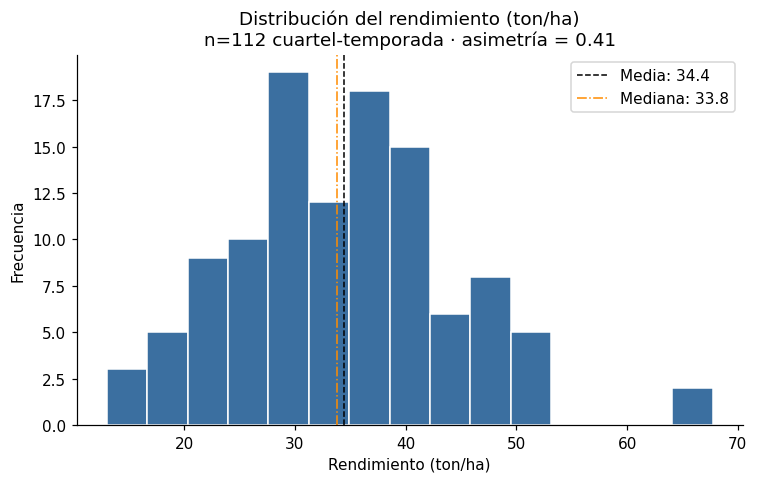

In [12]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(panel_full['ton_ha'], bins=15, color="#3B6FA0", edgecolor='white')
ax.axvline(panel_full['ton_ha'].mean(), color='black', ls='--', lw=1,
           label=f"Media: {panel_full['ton_ha'].mean():.1f}")
ax.axvline(panel_full['ton_ha'].median(), color='darkorange', ls='-.', lw=1,
           label=f"Mediana: {panel_full['ton_ha'].median():.1f}")
ax.set_title(f"Distribución del rendimiento (ton/ha)\nn={panel_full['ton_ha'].notna().sum()} cuartel-temporada · "
             f"asimetría = {panel_full['ton_ha'].skew():.2f}")
ax.set_xlabel("Rendimiento (ton/ha)"); ax.set_ylabel("Frecuencia")
ax.legend()
plt.tight_layout(); plt.show()


## Figura 2 — Rendimiento por temporada de cosecha

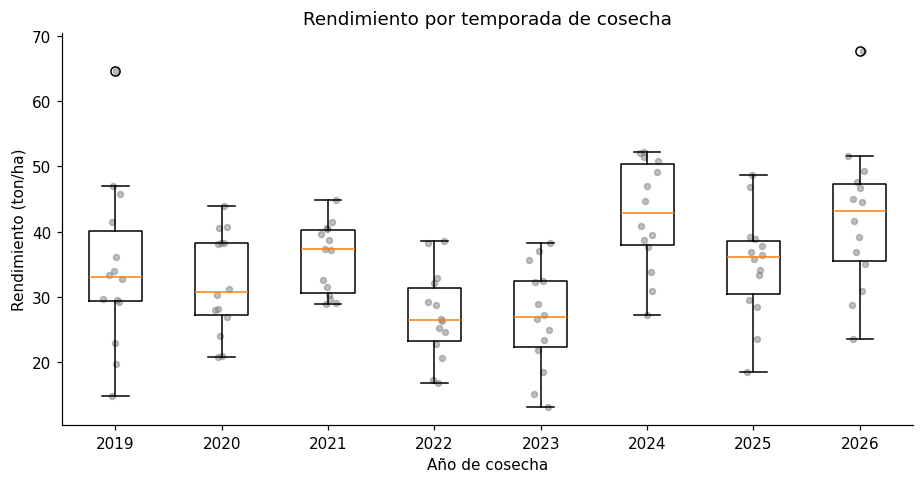

In [13]:
fig, ax = plt.subplots(figsize=(8.5, 4.5))
orden = sorted(panel_full['anio_cosecha'].unique())
datos_box = [panel_full.loc[panel_full['anio_cosecha'] == y, 'ton_ha'].dropna().values for y in orden]
ax.boxplot(datos_box, tick_labels=orden, showmeans=False)
rng = np.random.default_rng(0)
for i, y in enumerate(orden):
    vals = panel_full.loc[panel_full['anio_cosecha'] == y, 'ton_ha'].dropna().values
    ax.scatter(rng.normal(i + 1, 0.05, len(vals)), vals, alpha=0.5, s=15, color='gray')
ax.set_title("Rendimiento por temporada de cosecha")
ax.set_xlabel("Año de cosecha"); ax.set_ylabel("Rendimiento (ton/ha)")
plt.tight_layout(); plt.show()


## Figura 3 — Curva de canopia por temporada frente a la banda histórica

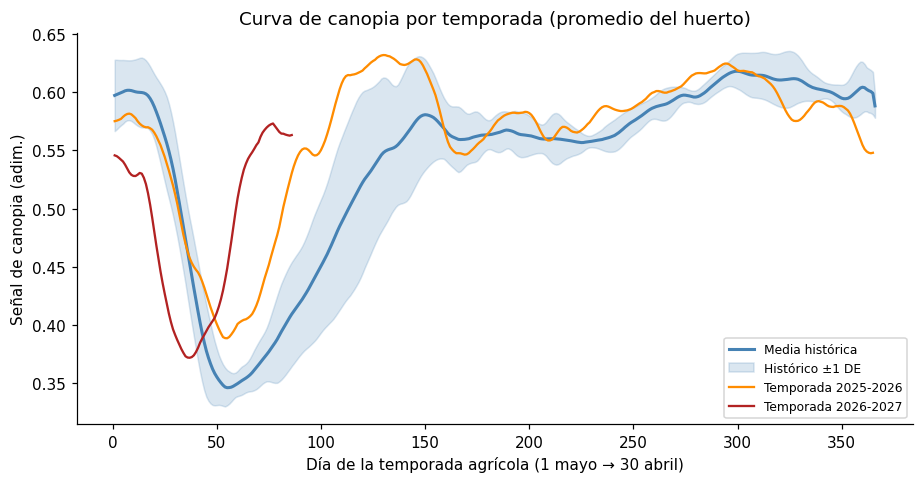

In [14]:
piv = canopy_diario.pivot_table(index='dia_temporada', columns='temporada',
                                 values='cb_invertido_suavizado', aggfunc='mean')

TEMPORADAS_RECIENTES = ['2025-2026', '2026-2027']  # temporadas a destacar frente al histórico
cols_hist = [c for c in piv.columns if c not in TEMPORADAS_RECIENTES]
media_hist = piv[cols_hist].mean(axis=1)
std_hist = piv[cols_hist].std(axis=1)

fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.plot(media_hist.index, media_hist, color='steelblue', lw=2, label='Media histórica')
ax.fill_between(media_hist.index, media_hist - std_hist, media_hist + std_hist,
                 color='steelblue', alpha=0.2, label='Histórico ±1 DE')
colores_recientes = {'2025-2026': 'darkorange', '2026-2027': 'firebrick'}
for t in TEMPORADAS_RECIENTES:
    if t in piv.columns:
        ax.plot(piv.index, piv[t], color=colores_recientes[t], lw=1.5, label=f'Temporada {t}')
ax.set_title("Curva de canopia por temporada (promedio del huerto)")
ax.set_xlabel("Día de la temporada agrícola (1 mayo → 30 abril)")
ax.set_ylabel("Señal de canopia (adim.)")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


## Figura 4 — Distribución de variables ambientales por temporada

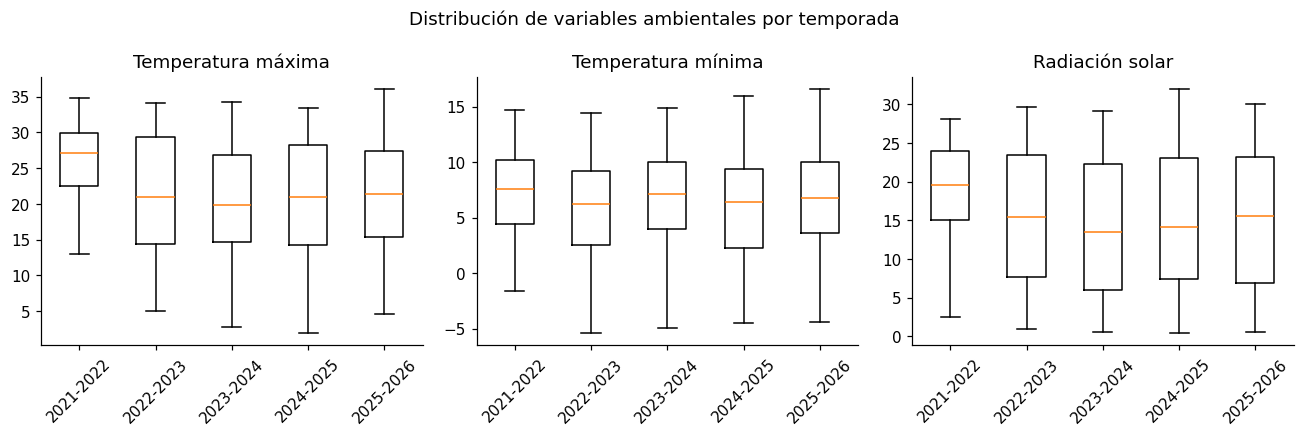

In [15]:
clima['temporada_plot'] = clima['temporada_agricola']
temporadas_validas = sorted([t for t in clima['temporada_plot'].unique()
                              if (clima['temporada_plot'] == t).sum() > 10 and t in temporadas])

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, col, titulo in zip(axes, ['tmax', 'tmin', 'rad'],
                            ['Temperatura máxima', 'Temperatura mínima', 'Radiación solar']):
    datos = [clima.loc[clima['temporada_plot'] == t, col].dropna().values for t in temporadas_validas]
    ax.boxplot(datos, tick_labels=temporadas_validas)
    ax.set_title(titulo)
    ax.tick_params(axis='x', rotation=45)
plt.suptitle("Distribución de variables ambientales por temporada")
plt.tight_layout(); plt.show()


## Figura 5 — Acumulación de horas de frío y grados-día base 7 °C

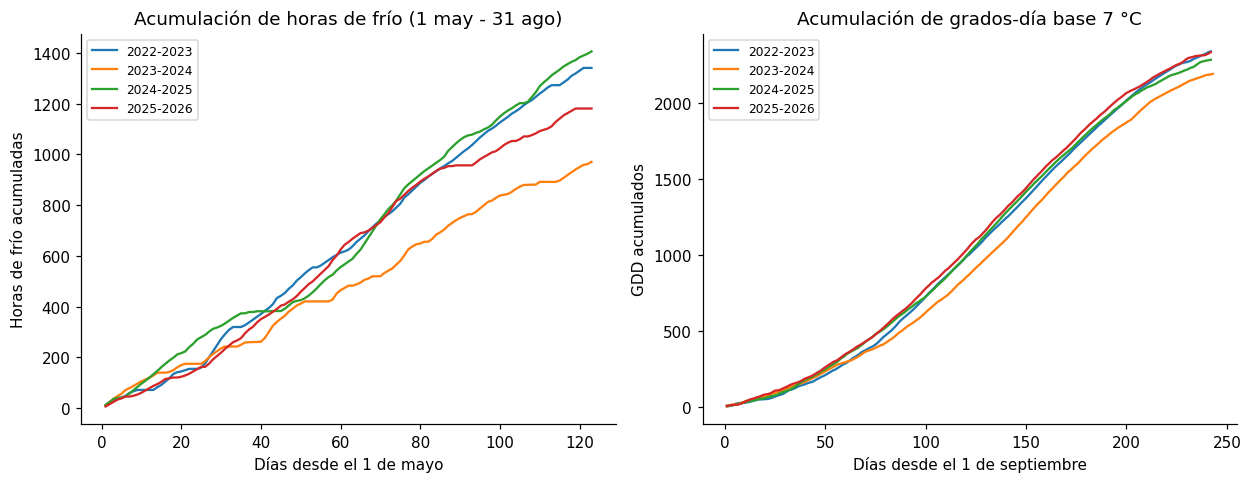

In [16]:
TEMPORADAS_CLIMA_COMPLETO = clima_feat.loc[clima_feat['invierno_completo'], 'temporada'].tolist()

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.5))
for t in TEMPORADAS_CLIMA_COMPLETO:
    y0 = int(t.split('-')[0])
    sub = clima[(clima['fecha'] >= f'{y0}-05-01') & (clima['fecha'] <= f'{y0}-08-31')].sort_values('fecha')
    axes[0].plot(range(1, len(sub) + 1), sub['chill_h_day'].cumsum(), label=t)
axes[0].set_title("Acumulación de horas de frío (1 may - 31 ago)")
axes[0].set_xlabel("Días desde el 1 de mayo"); axes[0].set_ylabel("Horas de frío acumuladas")
axes[0].legend(fontsize=8)

for t in TEMPORADAS_CLIMA_COMPLETO:
    y0 = int(t.split('-')[0])
    sub = clima[(clima['fecha'] >= f'{y0}-09-01') & (clima['fecha'] <= f'{y0+1}-04-30')].sort_values('fecha')
    axes[1].plot(range(1, len(sub) + 1), sub['gdd7'].cumsum(), label=t)
axes[1].set_title("Acumulación de grados-día base 7 °C")
axes[1].set_xlabel("Días desde el 1 de septiembre"); axes[1].set_ylabel("GDD acumulados")
axes[1].legend(fontsize=8)

plt.tight_layout(); plt.show()


## Figura 6 — Evapotranspiración de referencia (ETo) y de cultivo proxy (ETc)

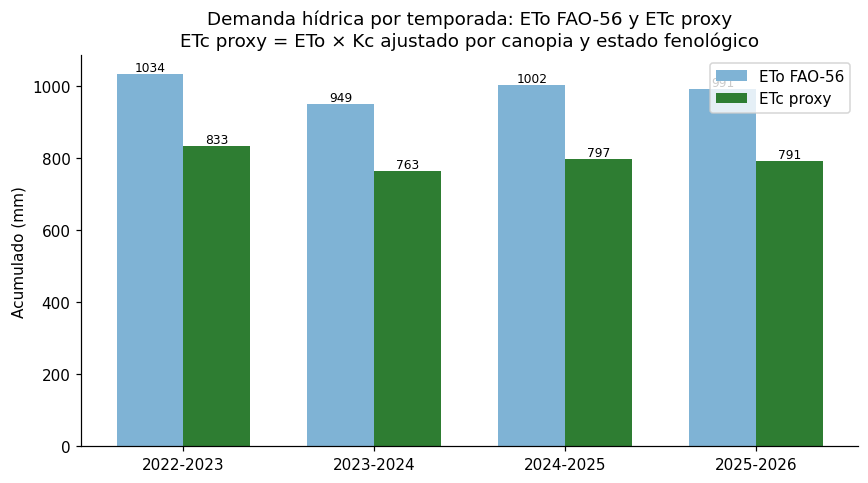

In [17]:
temporadas_plot = TEMPORADAS_CLIMA_COMPLETO
etos = eto_resumen.set_index('temporada').loc[temporadas_plot]

fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(temporadas_plot)); w = 0.35
b1 = ax.bar(x - w/2, etos['ETo_mm'], width=w, label='ETo FAO-56', color='#7FB3D5')
b2 = ax.bar(x + w/2, etos['ETc_proxy_mm'], width=w, label='ETc proxy', color='#2E7D32')
for bars in [b1, b2]:
    for bar in bars:
        ax.annotate(f"{bar.get_height():.0f}", (bar.get_x() + bar.get_width()/2, bar.get_height()),
                    ha='center', va='bottom', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(temporadas_plot)
ax.set_title("Demanda hídrica por temporada: ETo FAO-56 y ETc proxy\nETc proxy = ETo × Kc ajustado por canopia y estado fenológico")
ax.set_ylabel("Acumulado (mm)")
ax.legend()
plt.tight_layout(); plt.show()


## Figura 7 — Matriz de correlaciones entre variables cuantitativas

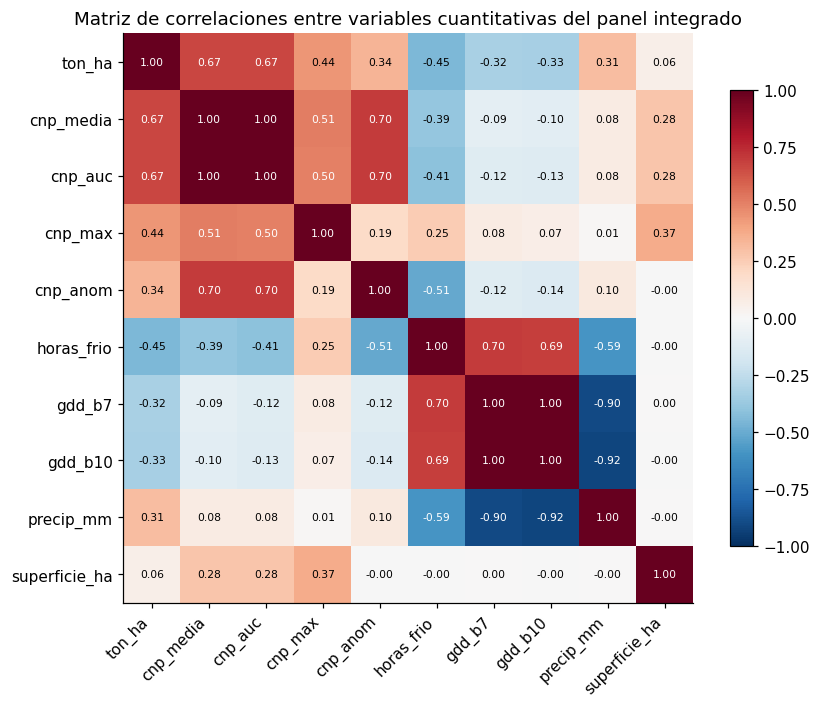

In [18]:
vars_corr = ['ton_ha', 'cnp_media', 'cnp_auc', 'cnp_max', 'cnp_anom',
             'horas_frio', 'gdd_b7', 'gdd_b10', 'precip_mm', 'superficie_ha']
corr = panel_full[vars_corr].corr()

fig, ax = plt.subplots(figsize=(8, 6.5))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(vars_corr))); ax.set_xticklabels(vars_corr, rotation=45, ha='right')
ax.set_yticks(range(len(vars_corr))); ax.set_yticklabels(vars_corr)
for i in range(len(vars_corr)):
    for j in range(len(vars_corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha='center', va='center', fontsize=7,
                color='white' if abs(corr.iloc[i, j]) > 0.5 else 'black')
plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_title("Matriz de correlaciones entre variables cuantitativas del panel integrado")
plt.tight_layout(); plt.show()


## Figura 8 — Canopia media de temporada vs. rendimiento

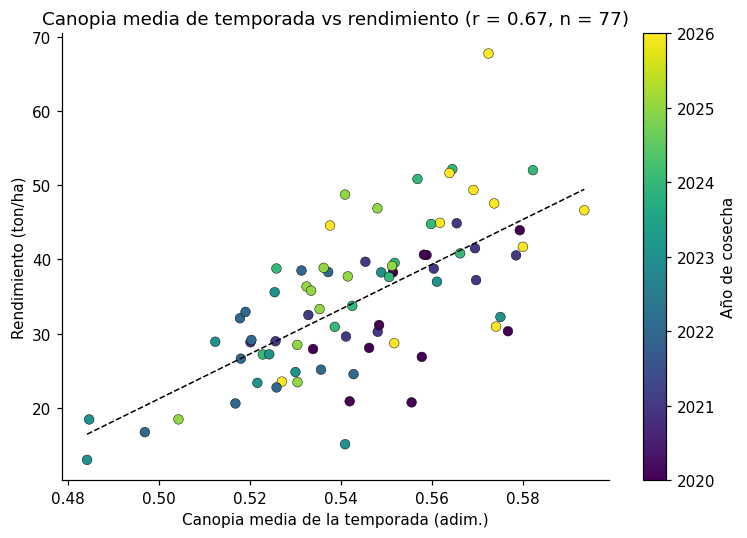

In [19]:
sub = panel_full.dropna(subset=['cnp_media', 'ton_ha'])
r = np.corrcoef(sub['cnp_media'], sub['ton_ha'])[0, 1]

fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(sub['cnp_media'], sub['ton_ha'], c=sub['anio_cosecha'], cmap='viridis',
                 s=40, edgecolor='k', linewidth=0.3)
z = np.polyfit(sub['cnp_media'], sub['ton_ha'], 1)
xs = np.linspace(sub['cnp_media'].min(), sub['cnp_media'].max(), 50)
ax.plot(xs, np.polyval(z, xs), 'k--', lw=1)
ax.set_title(f"Canopia media de temporada vs rendimiento (r = {r:.2f}, n = {len(sub)})")
ax.set_xlabel("Canopia media de la temporada (adim.)"); ax.set_ylabel("Rendimiento (ton/ha)")
plt.colorbar(sc, ax=ax, label='Año de cosecha')
plt.tight_layout(); plt.show()


## Figura 9 — Punto de equilibrio por hectárea y escenarios de rendimiento

Se usa la carta Gantt de costos (`Kiwis 2026 Gantt planificacion.xlsx`) para separar costos fijos por
hectárea (labores de mano de obra) de costos variables ligados al volumen (cosecha por bin). Los
escenarios pesimista / intermedio / optimista corresponden a los percentiles 10, 50 y 90 del
rendimiento histórico observado (empíricos, no supuestos).

**Recuerda:** este punto de equilibrio es un *piso*, ya que la carta Gantt solo cubre mano de obra y
cosecha (no insumos, fertilización, riego, energía ni administración), tal como advierte la sección 5.4
del informe.


Costo fijo por hectárea: $3,021,009 CLP/ha
Costo variable por kilo: $11.3 CLP/kg
Punto de equilibrio: 6.9 ton/ha (precio ref. $450/kg)


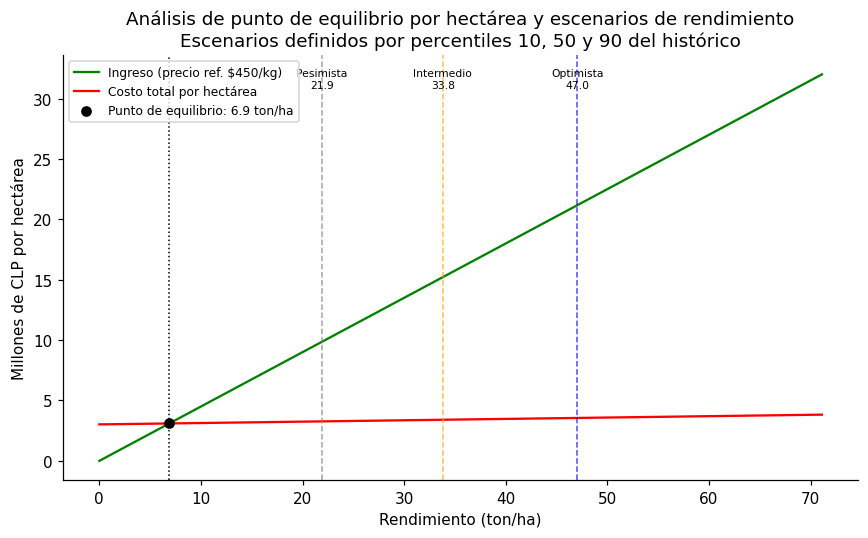

In [20]:
gantt = pd.read_excel(f"{FOLDER}/Kiwis 2026 Gantt planificacion.xlsx", sheet_name="kiwis", header=1)
gantt_act = gantt.dropna(subset=['Actividad'])

total_ha = panel_full.drop_duplicates('cuartel')['superficie_ha'].sum()
costo_cosecha_total = gantt_act.loc[gantt_act['Actividad'].str.strip() == 'COSECHA', 'Costo Total'].iloc[0]
costo_fijo_total = gantt_act.loc[gantt_act['Actividad'].str.strip() != 'COSECHA', 'Costo Total'].sum()
costo_fijo_ha = costo_fijo_total / total_ha

PESO_BIN_KG = 441            # kg promedio por bin (según informe)
VALOR_BIN_CLP = 5000         # costo de cosecha por bin
costo_var_kg = VALOR_BIN_CLP / PESO_BIN_KG

PRECIO_REF_CLP_KG = 450      # parámetro de precio de venta (ajustable)
margen_kg = PRECIO_REF_CLP_KG - costo_var_kg
pe_ton_ha = costo_fijo_ha / (margen_kg * 1000)

print(f"Costo fijo por hectárea: ${costo_fijo_ha:,.0f} CLP/ha")
print(f"Costo variable por kilo: ${costo_var_kg:,.1f} CLP/kg")
print(f"Punto de equilibrio: {pe_ton_ha:.1f} ton/ha (precio ref. ${PRECIO_REF_CLP_KG}/kg)")

p10, p50, p90 = np.nanpercentile(panel_full['ton_ha'], [10, 50, 90])

xs = np.linspace(0, panel_full['ton_ha'].max() * 1.05, 50)
ingreso = xs * 1000 * PRECIO_REF_CLP_KG / 1e6
costo_total = (costo_fijo_ha + xs * 1000 * costo_var_kg) / 1e6

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(xs, ingreso, color='green', label=f'Ingreso (precio ref. ${PRECIO_REF_CLP_KG}/kg)')
ax.plot(xs, costo_total, color='red', label='Costo total por hectárea')
ax.axvline(pe_ton_ha, color='black', ls=':', lw=1)
ax.scatter([pe_ton_ha], [(costo_fijo_ha + pe_ton_ha * 1000 * costo_var_kg) / 1e6], color='black', zorder=5,
           label=f'Punto de equilibrio: {pe_ton_ha:.1f} ton/ha')

for p, etiqueta, color in [(p10, 'Pesimista', 'gray'), (p50, 'Intermedio', 'orange'), (p90, 'Optimista', 'blue')]:
    ax.axvline(p, color=color, ls='--', lw=1, alpha=0.7)
    ax.text(p, ax.get_ylim()[1] * 0.92, f"{etiqueta}\n{p:.1f}", fontsize=7, ha='center')

ax.set_title("Análisis de punto de equilibrio por hectárea y escenarios de rendimiento\n"
             "Escenarios definidos por percentiles 10, 50 y 90 del histórico")
ax.set_xlabel("Rendimiento (ton/ha)"); ax.set_ylabel("Millones de CLP por hectárea")
ax.legend(loc='upper left', fontsize=8)
plt.tight_layout(); plt.show()


## 7. (Opcional) Exportar el panel integrado a Excel/CSV

Guarda el panel consolidado para reutilizarlo en la Entrega N°2 (modelado predictivo).


In [21]:
panel_full.to_csv("panel_integrado_kiwi_chimbarongo.csv", index=False)
print("Archivo guardado: panel_integrado_kiwi_chimbarongo.csv")

# Para descargarlo directamente desde Colab, descomenta:
# from google.colab import files
# files.download("panel_integrado_kiwi_chimbarongo.csv")


Archivo guardado: panel_integrado_kiwi_chimbarongo.csv
